In [1]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
import json
from pprint import pprint

from tqdm.auto import tqdm
from pysolotools.consumers import Solo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import cv2

import torch
import torch.nn.functional as F
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'torch device: {device}')
# GNN package
import torch_geometric.nn as pyg
from torch_geometric.data import Data, Dataset, InMemoryDataset, download_url
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, EdgeCNN

# graph package
import networkx as nx
from networkx.algorithms import isomorphism

# to make ploty render properly
import plotly.io as pio
pio.renderers.default = 'iframe'

torch device: mps


In [2]:
SOLO_NAME = 'solo_1'
DATA_DIR = '../output'
DATA_PATH = f'{DATA_DIR}/{SOLO_NAME}'

OUTPUT_DIR = './tmp'
OUTPUT_PATH = f'{OUTPUT_DIR}/query-onObj/{SOLO_NAME}'
if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH, exist_ok=True)
    print(f'create folder: {OUTPUT_PATH}')

create folder: ./tmp/query-onObj/solo_1


In [3]:
solo = Solo(DATA_PATH)

# utility
CAM_FOV = 60.0
label2name_dict = solo.categories()
name2label_dict = {v:k for k, v in label2name_dict.items()}

## Visualization

In [4]:
def vis_azimuth(df, data_col, name_col, title='azimuth'):
    vis_df = pd.DataFrame({'vis_x': np.cos(df[data_col]), 'vis_y': np.sin(df[data_col]), 'labelName': df[name_col]}, index=df.index)
    fig = px.scatter(vis_df, x='vis_x', y='vis_y', color='labelName')
    fig.update_layout(
        title=title,
        autosize=False,
        width=400,
        height=400,
    )
    fig.update_xaxes(range=[-1.2, 1.2])
    fig.update_yaxes(range=[-1.2, 1.2])
    return fig

## Utilites

In [5]:
def save_file(path, name, df, cam_info, verbose=True):
    df.to_csv(f'{path}/{name}.csv')
    json.dump(cam_info, open(f'{path}/{name}.json', 'w'), indent=4)
    if verbose:
        print(f'save to "{path}/{name}" successfully')

In [6]:
def get_cam_dict(cap):
    cam_dict = {
        'pos_x': cap.position[0],
        'pos_y': cap.position[1],
        'pos_z': cap.position[2],
        # 'rotation': cap.rotation,
    }
    return cam_dict

## Preprocess metadata

In [7]:
def prep_metadata(metrics_df):
    meta = metrics_df.set_index('id').loc['metadata', 'values'][0]['instances']
    # set instanceId as index
    meta_df = pd.DataFrame(list(map(lambda obj: {'instanceId': obj['instanceId'], **obj['my_object_metadata']}, meta))).astype({'instanceId': 'int'}).set_index('instanceId')

    # process fields to expected formats
    abs_pos_df = pd.DataFrame(meta_df['absPos'].values.tolist(), index=meta_df.index, columns=['abs_x', 'abs_y', 'abs_z'])
    rel_pos_to_cam_df = pd.DataFrame(meta_df['relPosToCam'].values.tolist(), index=meta_df.index, columns=['rel_x', 'rel_y', 'rel_z'])
    
    meta_df = pd.concat((meta_df, abs_pos_df, rel_pos_to_cam_df), axis=1)
    meta_df = meta_df.drop(columns=['absPos', 'relPosToCam'])
    return meta_df

In [8]:
def cart_to_sph_df(x, y, z, index):
    # radial distance, inclination (or elevation), and azimuth
    x_2 = x**2
    y_2 = y**2
    z_2 = z**2
    xz = np.sqrt(x_2 + z_2)

    r = np.sqrt(x_2 + y_2 + z_2)
    inc = np.arctan2(y, xz)
    azi = np.arctan2(z, x)
    
    return pd.DataFrame({'sph_r': r, 'sph_elevation': inc, 'sph_azimuth': azi}, index=index)

## In-Scene Preprocess

In [9]:
f = list(solo.frames())[5]
cap = f.captures[0]
cam_dict = get_cam_dict(cap)
metrics_df = f.get_metrics_df()
meta_df = prep_metadata(metrics_df)
meta_df

/Users/alan/Documents/ELSA/Woven/Scene/SimpleOffice-Raycast_Demo/py/venv/lib/python3.11/site-packages/dataclasses_json/core.py:180: RuntimeWarning:

`NoneType` object value of non-optional type filename detected when decoding RGBCameraCapture.



,labelName,distToCam,isBlockToCam,onObjectLabel,onObjectInstanceId,abs_x,abs_y,abs_z,rel_x,rel_y,rel_z
instanceId,,,,,,,,,,,
1,storage,10.287367,True,Ground,-1,-15.7450,6.1000,-12.930,-9.7450,-1.2000,3.070
2,cup,16.443615,False,Ground,-1,-5.3890,6.4644,0.411,0.6110,-0.8356,16.411
3,storage,13.369645,False,Ground,-1,-3.0730,6.1000,-3.010,2.9270,-1.2000,12.990
4,poster,15.202441,False,Ground,-1,-3.0490,7.9050,-1.099,2.9510,0.6050,14.901
5,plant,16.533762,False,Ground,-1,-8.3420,6.1000,0.323,-2.3420,-1.2000,16.323
...,...,...,...,...,...,...,...,...,...,...,...
510,cup,22.087591,True,table,505,-27.5710,6.9220,-11.266,-21.5710,-0.3780,4.734
511,sink,23.422653,True,Ground,-1,-23.0490,6.1000,0.016,-17.0490,-1.2000,16.016
512,paper,23.479763,True,Ground,-1,-28.3420,6.1000,-8.880,-22.3420,-1.2000,7.120


In [10]:
sph_df = cart_to_sph_df(meta_df['rel_x'], meta_df['rel_y'], meta_df['rel_z'], meta_df.index)
sph_df

,sph_r,sph_elevation,sph_azimuth
instanceId,,,
1,10.287367,-0.116914,2.836402
2,16.443615,-0.050838,1.533582
3,13.369646,-0.089877,1.349170
4,15.202441,0.039807,1.375286
5,16.533762,-0.072643,1.713302
...,...,...,...
510,22.087591,-0.017115,2.925556
511,23.422653,-0.051255,2.387426
512,23.479765,-0.051130,2.833085


In [11]:
obj_df = pd.concat((meta_df, sph_df), axis=1)
obj_df

,labelName,distToCam,isBlockToCam,onObjectLabel,onObjectInstanceId,abs_x,abs_y,abs_z,rel_x,rel_y,rel_z,sph_r,sph_elevation,sph_azimuth
instanceId,,,,,,,,,,,,,,
1,storage,10.287367,True,Ground,-1,-15.7450,6.1000,-12.930,-9.7450,-1.2000,3.070,10.287367,-0.116914,2.836402
2,cup,16.443615,False,Ground,-1,-5.3890,6.4644,0.411,0.6110,-0.8356,16.411,16.443615,-0.050838,1.533582
3,storage,13.369645,False,Ground,-1,-3.0730,6.1000,-3.010,2.9270,-1.2000,12.990,13.369646,-0.089877,1.349170
4,poster,15.202441,False,Ground,-1,-3.0490,7.9050,-1.099,2.9510,0.6050,14.901,15.202441,0.039807,1.375286
5,plant,16.533762,False,Ground,-1,-8.3420,6.1000,0.323,-2.3420,-1.2000,16.323,16.533762,-0.072643,1.713302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,cup,22.087591,True,table,505,-27.5710,6.9220,-11.266,-21.5710,-0.3780,4.734,22.087591,-0.017115,2.925556
511,sink,23.422653,True,Ground,-1,-23.0490,6.1000,0.016,-17.0490,-1.2000,16.016,23.422653,-0.051255,2.387426
512,paper,23.479763,True,Ground,-1,-28.3420,6.1000,-8.880,-22.3420,-1.2000,7.120,23.479765,-0.051130,2.833085


In [12]:
vis_azimuth(obj_df[obj_df['isBlockToCam'] == False], 'sph_azimuth', 'labelName')

In [13]:
color_map = { np.unique(obj_df['labelName'])[i]: px.colors.qualitative.Light24[i % 24] for i in range(len(np.unique(obj_df['labelName']))) }
color_map['camera'] = '#000000'
tmp = obj_df[obj_df['isBlockToCam'] == False]

cam_pos = [cam_dict[x] for x in ['pos_x', 'pos_y', 'pos_z']]
obj_x = tmp['abs_x']
obj_y = tmp['abs_y']
obj_z = tmp['abs_z']
obj_label = tmp['labelName']

In [14]:
tmp = pd.concat((obj_label, pd.DataFrame([{'pos': v.values} for _, v in pd.concat((obj_x, obj_y, obj_z), axis=1).iterrows()], index=obj_label.index)), axis=1)
tmp

G = nx.Graph()
G.add_node('camera', pos=cam_pos, labelName='camera')
for idx, row in tmp.iterrows():
    G.add_node(idx, pos=row['pos'], labelName=row['labelName'])
    G.add_edge('camera', idx)

In [15]:
edge_x = []
edge_y = []
for edge in G.edges():
    x0, _, y0 = G.nodes[edge[0]]['pos']
    x1, _, y1 = G.nodes[edge[1]]['pos']
    edge_x.append(x0)
    edge_x.append(x1)
    edge_x.append(None)
    edge_y.append(y0)
    edge_y.append(y1)
    edge_y.append(None)

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    mode='lines'
)

node_x = []
node_y = []
for node in G.nodes():
    x, _, y = G.nodes[node]['pos']
    node_x.append(x)
    node_y.append(y)

node_text = list(nx.get_node_attributes(G, 'labelName').values())

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    # hoverinfo='text',
    text=node_text,
    marker=dict(
        color=[color_map[text] for text in node_text],
        size=10,
        line_width=2
    ),
    name='node',
)

In [16]:
fig = go.Figure(data=[edge_trace, node_trace])
fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
)
fig.show()

In [191]:
# cam_dict = get_cam_dict(cap)
# save_file(OUTPUT_DIR, 'map', obj_df, cam_dict)

# "On" relation Graph

In [28]:
ground_row = pd.DataFrame({'labelName': 'ground', 'onObjectInstanceId': -1}, index=[-1])
on_df = pd.concat((ground_row, obj_df), axis=0)
on_df = on_df.reset_index(names=['instanceId'])
on_df

,instanceId,labelName,onObjectInstanceId,distToCam,isBlockToCam,onObjectLabel,abs_x,abs_y,abs_z,rel_x,rel_y,rel_z,sph_r,sph_elevation,sph_azimuth
0,-1,ground,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,storage,-1,10.287367,True,Ground,-15.7450,6.1000,-12.930,-9.7450,-1.2000,3.070,10.287367,-0.116914,2.836402
2,2,cup,-1,16.443615,False,Ground,-5.3890,6.4644,0.411,0.6110,-0.8356,16.411,16.443615,-0.050838,1.533582
3,3,storage,-1,13.369645,False,Ground,-3.0730,6.1000,-3.010,2.9270,-1.2000,12.990,13.369646,-0.089877,1.349170
4,4,poster,-1,15.202441,False,Ground,-3.0490,7.9050,-1.099,2.9510,0.6050,14.901,15.202441,0.039807,1.375286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,510,cup,505,22.087591,True,table,-27.5710,6.9220,-11.266,-21.5710,-0.3780,4.734,22.087591,-0.017115,2.925556
511,511,sink,-1,23.422653,True,Ground,-23.0490,6.1000,0.016,-17.0490,-1.2000,16.016,23.422653,-0.051255,2.387426
512,512,paper,-1,23.479763,True,Ground,-28.3420,6.1000,-8.880,-22.3420,-1.2000,7.120,23.479765,-0.051130,2.833085
513,513,socket,-1,3.190439,False,Ground,-3.0000,6.6000,-16.830,3.0000,-0.7000,-0.830,3.190439,-0.221205,-0.269915


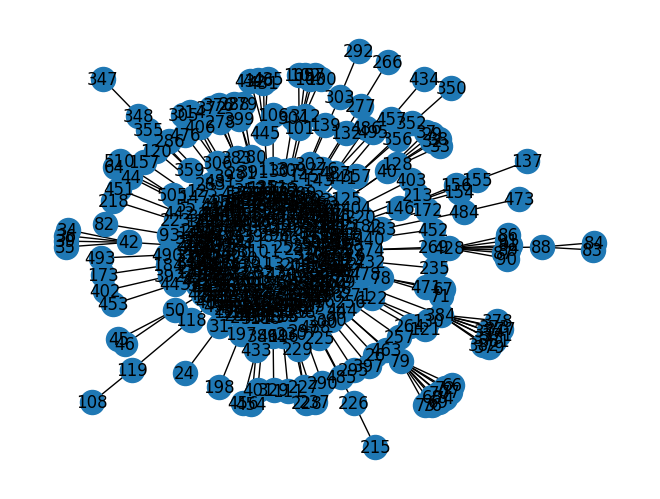

In [36]:
G = nx.from_pandas_edgelist(on_df, 'instanceId', 'onObjectInstanceId')
node_attr = on_df[['instanceId', 'labelName']].set_index('instanceId').to_dict('index')
nx.set_node_attributes(G, node_attr)
nx.draw(G, with_labels=True)

In [64]:
for k, deg in dict(nx.degree(G)).items():
    if deg > 1:
        print(k, deg)

-1 387
31 2
30 2
40 6
42 5
55 2
50 3
505 3
79 10
78 3
93 2
88 3
428 8
101 6
113 2
119 2
116 2
118 2
123 2
122 3
125 2
143 2
155 2
145 2
146 4
147 2
182 2
184 2
197 2
220 2
226 2
223 2
225 2
230 2
229 3
232 2
256 2
271 2
277 2
274 2
276 2
281 2
280 3
283 2
297 2
303 2
300 2
302 2
307 2
306 3
309 2
469 2
348 2
359 3
352 2
357 3
384 10
383 3
389 2
390 2
391 2
392 2
393 2
404 2
445 5
433 3
457 2
440 2
441 2
442 2
443 2
444 2
478 2
484 2
481 2
483 2
488 2
487 3
490 2


## Generate Data

In [192]:
for f in tqdm(solo.frames()):
    cap = f.captures[0]
    metrics_df = f.get_metrics_df()
    meta_df = prep_metadata(metrics_df)

    # composed features
    sph_df = cart_to_sph_df(meta_df['rel_x'], meta_df['rel_y'], meta_df['rel_z'], meta_df.index)

    obj_df = pd.concat((meta_df, sph_df), axis=1)
    cam_dict = get_cam_dict(cap)

    # save to file
    save_file(OUTPUT_PATH, f.step, obj_df, cam_dict, verbose=True)

  0%|          | 0/26 [00:00<?, ?it/s]

/Users/alan/Documents/ELSA/Woven/Scene/SimpleOffice-Raycast_Demo/py/venv/lib/python3.11/site-packages/dataclasses_json/core.py:180: RuntimeWarning:

`NoneType` object value of non-optional type filename detected when decoding RGBCameraCapture.

/Users/alan/Documents/ELSA/Woven/Scene/SimpleOffice-Raycast_Demo/py/venv/lib/python3.11/site-packages/dataclasses_json/core.py:180: RuntimeWarning:

`NoneType` object value of non-optional type filename detected when decoding RGBCameraCapture.

/Users/alan/Documents/ELSA/Woven/Scene/SimpleOffice-Raycast_Demo/py/venv/lib/python3.11/site-packages/dataclasses_json/core.py:180: RuntimeWarning:

`NoneType` object value of non-optional type filename detected when decoding RGBCameraCapture.

/Users/alan/Documents/ELSA/Woven/Scene/SimpleOffice-Raycast_Demo/py/venv/lib/python3.11/site-packages/dataclasses_json/core.py:180: RuntimeWarning:

`NoneType` object value of non-optional type filename detected when decoding RGBCameraCapture.

/Users/alan/Document

save to "./tmp/map/map_rooms_26/0" successfully
save to "./tmp/map/map_rooms_26/1" successfully
save to "./tmp/map/map_rooms_26/2" successfully
save to "./tmp/map/map_rooms_26/3" successfully
save to "./tmp/map/map_rooms_26/4" successfully
save to "./tmp/map/map_rooms_26/5" successfully
save to "./tmp/map/map_rooms_26/6" successfully
save to "./tmp/map/map_rooms_26/7" successfully
save to "./tmp/map/map_rooms_26/8" successfully
save to "./tmp/map/map_rooms_26/9" successfully
save to "./tmp/map/map_rooms_26/10" successfully
save to "./tmp/map/map_rooms_26/11" successfully
save to "./tmp/map/map_rooms_26/12" successfully
save to "./tmp/map/map_rooms_26/13" successfully
save to "./tmp/map/map_rooms_26/14" successfully
save to "./tmp/map/map_rooms_26/15" successfully
save to "./tmp/map/map_rooms_26/16" successfully
save to "./tmp/map/map_rooms_26/17" successfully
save to "./tmp/map/map_rooms_26/18" successfully
save to "./tmp/map/map_rooms_26/19" successfully
save to "./tmp/map/map_rooms_2

/Users/alan/Documents/ELSA/Woven/Scene/SimpleOffice-Raycast_Demo/py/venv/lib/python3.11/site-packages/dataclasses_json/core.py:180: RuntimeWarning:

`NoneType` object value of non-optional type filename detected when decoding RGBCameraCapture.

/Users/alan/Documents/ELSA/Woven/Scene/SimpleOffice-Raycast_Demo/py/venv/lib/python3.11/site-packages/dataclasses_json/core.py:180: RuntimeWarning:

`NoneType` object value of non-optional type filename detected when decoding RGBCameraCapture.

/Users/alan/Documents/ELSA/Woven/Scene/SimpleOffice-Raycast_Demo/py/venv/lib/python3.11/site-packages/dataclasses_json/core.py:180: RuntimeWarning:

`NoneType` object value of non-optional type filename detected when decoding RGBCameraCapture.

